In [26]:
import pandas as pd
import numpy as np

pd.set_option('display.max_rows', 500) #capability

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt


In [27]:
df = pd.read_csv("/cleaned_5250.csv") #creamos una variable que lee el archivo (un data frame en base al csv)

In [7]:
df.head() #muestra 5 primeras filas de la tabla

,name,distance,stellar_magnitude,planet_type,discovery_year,mass_multiplier,mass_wrt,radius_multiplier,radius_wrt,orbital_radius,orbital_period,eccentricity,detection_method
0,11 Comae Berenices b,304.0,4.72307,Gas Giant,2007,19.40000,Jupiter,1.08,Jupiter,1.290000,0.892539,0.23,Radial Velocity
1,11 Ursae Minoris b,409.0,5.01300,Gas Giant,2009,14.74000,Jupiter,1.09,Jupiter,1.530000,1.400000,0.08,Radial Velocity
2,14 Andromedae b,246.0,5.23133,Gas Giant,2008,4.80000,Jupiter,1.15,Jupiter,0.830000,0.508693,0.00,Radial Velocity
3,14 Herculis b,58.0,6.61935,Gas Giant,2002,8.13881,Jupiter,1.12,Jupiter,2.773069,4.800000,0.37,Radial Velocity
4,16 Cygni B b,69.0,6.21500,Gas Giant,1996,1.78000,Jupiter,1.20,Jupiter,1.660000,2.200000,0.68,Radial Velocity


In [8]:
df.tail() #muestra 5 ultimas filas de la tabla

,name,distance,stellar_magnitude,planet_type,discovery_year,mass_multiplier,mass_wrt,radius_multiplier,radius_wrt,orbital_radius,orbital_period,eccentricity,detection_method
5245,XO-7 b,764.0,10.521,Gas Giant,2019,0.709,Jupiter,1.373,Jupiter,0.04421,0.007940,0.04,Transit
5246,YSES 2 b,357.0,10.885,Gas Giant,2021,6.300,Jupiter,1.140,Jupiter,115.00000,1176.500000,0.00,Direct Imaging
5247,YZ Ceti b,12.0,12.074,Terrestrial,2017,0.700,Earth,0.913,Earth,0.01634,0.005476,0.06,Radial Velocity
5248,YZ Ceti c,12.0,12.074,Super Earth,2017,1.140,Earth,1.050,Earth,0.02156,0.008487,0.00,Radial Velocity
5249,YZ Ceti d,12.0,12.074,Super Earth,2017,1.090,Earth,1.030,Earth,0.02851,0.012868,0.07,Radial Velocity


In [9]:
df.columns #muestra columnas categoricas

Index(['name', 'distance', 'stellar_magnitude', 'planet_type',
       'discovery_year', 'mass_multiplier', 'mass_wrt', 'radius_multiplier',
       'radius_wrt', 'orbital_radius', 'orbital_period', 'eccentricity',
       'detection_method'],
      dtype='object')

In [10]:
df.shape #muestra numero de filas y cantidad de columnas

(5250, 13)

In [11]:
df.info() #muestra tipos de atos nulos en el dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5250 entries, 0 to 5249
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               5250 non-null   object 
 1   distance           5233 non-null   float64
 2   stellar_magnitude  5089 non-null   float64
 3   planet_type        5250 non-null   object 
 4   discovery_year     5250 non-null   int64  
 5   mass_multiplier    5227 non-null   float64
 6   mass_wrt           5227 non-null   object 
 7   radius_multiplier  5233 non-null   float64
 8   radius_wrt         5233 non-null   object 
 9   orbital_radius     4961 non-null   float64
 10  orbital_period     5250 non-null   float64
 11  eccentricity       5250 non-null   float64
 12  detection_method   5250 non-null   object 
dtypes: float64(7), int64(1), object(5)
memory usage: 533.3+ KB


In [13]:
df['stellar_magnitude'].value_counts() #muestra info de columna categorica

,count
stellar_magnitude,
8.97000,15
8.05000,10
14.37900,10
8.23000,9
7.49000,9
...,...
5.35320,1
12.61800,1
5.51048,1


In [28]:
df['stellar_magnitude'].value_counts().count() #muestra cantidad de columnas en variable categorica

np.int64(2875)

In [16]:
df['planet_type'].value_counts()

,count
planet_type,
Neptune-like,1825
Gas Giant,1630
Super Earth,1595
Terrestrial,195
Unknown,5


In [18]:
df.isnull().sum() #mostrara la cantidad de nulos por columna

,0
name,0
distance,17
stellar_magnitude,161
planet_type,0
discovery_year,0
mass_multiplier,23
mass_wrt,23
radius_multiplier,17
radius_wrt,17
orbital_radius,289


In [19]:
df.describe().round() #estadistica en variables numericas #round borra los decimales

,distance,stellar_magnitude,discovery_year,mass_multiplier,radius_multiplier,orbital_radius,orbital_period,eccentricity
count,5233.0,5089.0,5250.0,5227.0,5233.0,4961.0,5250.0,5250.0
mean,2167.0,13.0,2016.0,6.0,1.0,7.0,479.0,0.0
std,3246.0,3.0,4.0,13.0,1.0,139.0,16804.0,0.0
min,4.0,1.0,1992.0,0.0,0.0,0.0,0.0,-1.0
25%,389.0,11.0,2014.0,2.0,0.0,0.0,0.0,0.0
50%,1371.0,14.0,2016.0,4.0,1.0,0.0,0.0,0.0
75%,2779.0,15.0,2018.0,8.0,1.0,0.0,0.0,0.0
max,27727.0,45.0,2023.0,752.0,7.0,7506.0,1101370.0,1.0


In [20]:
df_limpio = df.dropna() #borra nulos

In [21]:
df_limpio.to_csv("nuevo_csv_limpio.csv") #guardar una copia de csv limpio

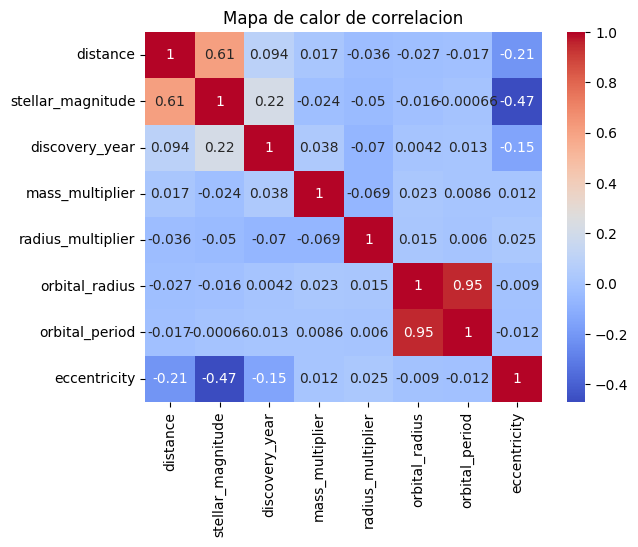

In [40]:
corr = df.select_dtypes(include='number').corr() #probar con correlacion

#plt.figure(figsize=(20,18))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Mapa de calor de correlacion")
plt.show()